In [178]:
! pip install uncertainties

     ---------------------------------------- 58.3/58.3 kB 1.5 MB/s eta 0:00:00


In [179]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from where_linear import LinearDomainFinder
from uncertainties import umath

In [10]:
LDF = LinearDomainFinder()

In [16]:
df = pd.read_csv("vg_csv_test.csv")

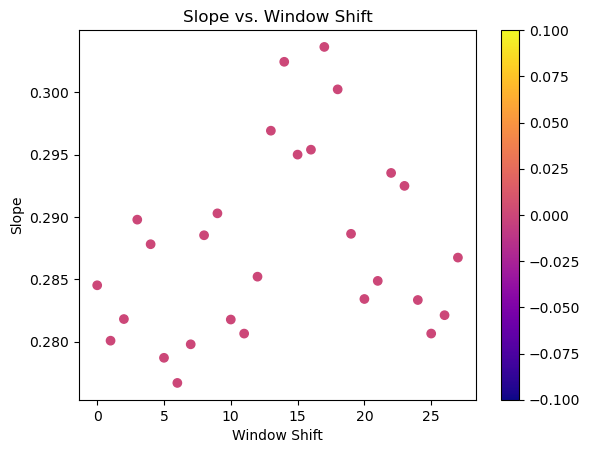

None


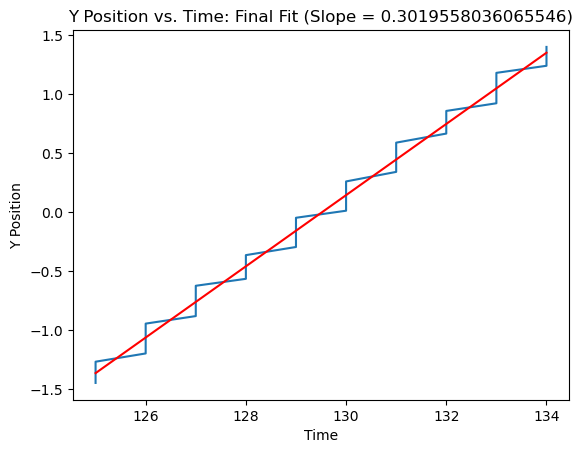

[  0.3019558  -39.11143072]


In [130]:
LDF.setVerbosity(1)
LDF.setX(df["t"][min:max],label="Time")
LDF.setY(df["y"][min:max],label="Y Position")
LDF.slidingWindowFind(WIN_SIZE=20,FDEV_CUT=0.2)
print(LDF.popt)


In [26]:
print(LDF.LLD)

In [29]:
df["t"][0:100]

0      0.000
1      0.213
2      0.426
3      0.638
4      0.851
       ...  
95    20.200
96    20.400
97    20.600
98    20.900
99    21.100
Name: t, Length: 100, dtype: float64

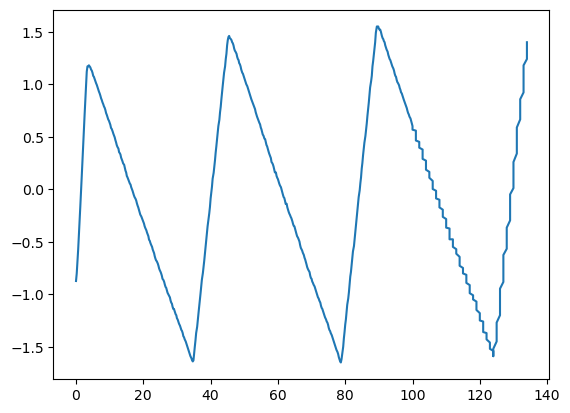

In [174]:
fig,ax = plt.subplots()
min=586
max=len(df["t"])+100
#ax.plot(df["t"][min:max],df["y"][min:max])
ax.plot(df.t,df.y)


In [133]:
ve1 = 0.09277733117160546
ve2 = 0.09474541217227998
ve3 = 0.09179359262300867
vg1 = 0.2988007625464431
vg2 = 0.30374033136659373
vg3 = 0.3019558036065546


In [195]:
vg = np.mean([vg1,vg2,vg3])
ve = np.mean([ve1,ve2,ve3])
np.std([vg1,vg2,vg3])
#np.std([ve1,ve2,ve3])

0.002042279868359104

In [135]:
vg

0.30149896583986385

In [ ]:
ve

0.09310544532229803

In [191]:
def q(ve,vg):
    d = 4.56e-3 # m
    V = 400 # V
    eta = 18.13e-6 #N*s/m^2
    b = 6.17e-6 # m*cmHg
    P = 76 #cmHg
    rho = 0.86e3 #kg/m^3
    g = 9.801 #m/s^2
    a = np.sqrt((9*eta*vg)/(2*g*rho))
    return [a,((6*np.pi*d/V)*np.sqrt((9*eta**3)/(2*rho*g))*(ve+vg)*(np.sqrt(vg))*(1+(b/(a*P)))**(-3/2))]


In [192]:
q(ve*10**-3,vg*10**-3)

[1.7082980774613358e-06, 2.449535502776281e-18]